# Proyecto final - DS Telecom

Al operador de telecomunicaciones Interconnect le gustaría poder pronosticar su tasa de cancelación de clientes. Si se descubre que un usuario o usuaria planea irse, se le ofrecerán códigos promocionales y opciones de planes especiales. El equipo de marketing de Interconnect ha
recopilado algunos de los datos personales de sus clientes, incluyendo información sobre sus planes y contratos.

### Servicios de Interconnect

Interconnect proporciona principalmente dos tipos de servicios:
1. Comunicación por teléfono fijo. El teléfono se puede conectar a varias líneas de manera simultánea.
2. Internet. La red se puede configurar a través de una línea telefónica (DSL, línea de abonado digital) o a través de un cable de fibra óptica.

Algunos otros servicios que ofrece la empresa incluyen:

* Seguridad en Internet: software antivirus (ProtecciónDeDispositivo) y un bloqueador de sitios web maliciosos (SeguridadEnLínea).
* Una línea de soporte técnico (SoporteTécnico).
* Almacenamiento de archivos en la nube y backup de datos (BackupOnline).
* Streaming de TV (StreamingTV) y directorio de películas (StreamingPelículas)

La clientela puede elegir entre un pago mensual o firmar un contrato de 1 o 2 años. Puede utilizar varios métodos de pago y recibir una factura electrónica después de una transacción.

### Descripción de los datos

Los datos consisten en archivos obtenidos de diferentes fuentes:

* contract.csv — información del contrato;
* personal.csv — datos personales del cliente;
* internet.csv — información sobre los servicios de Internet;
* phone.csv — información sobre los servicios telefónicos.

En cada archivo, la columna `customerID` contiene un código único asignado a cada cliente. La información del contrato es válida a partir del 1 de febrero de 2020.

### Objetivo

El objetivo final del proyecto será desarrollar un modelo de aprendizaje automático capaz de predecir la cancelación de clientes (churn), utilizando información contractual, demográfica y relacionada con los servicios contratados

## 1. Análisis exploratorio de datos

Como primer paso, se realizará una exploración inicial de los datos para comprender su estructura, calidad y posibles relaciones con el problema de negocio.

### 1.1 Importación de archivos

In [1]:
# Carga de librerías
import pandas as pd
import numpy as np
import re
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score


# Configuración para visualizar más columnas
pd.set_option('display.max_columns', None)

# Configuración para mostrar números con dos decimales
pd.options.display.float_format = '{:.2f}'.format

In [2]:
# Cargar datasets
contract = pd.read_csv("/datasets/final_provider/contract.csv")
personal = pd.read_csv("/datasets/final_provider/personal.csv")
internet = pd.read_csv("/datasets/final_provider/internet.csv")
phone = pd.read_csv("/datasets/final_provider/phone.csv")

### 1.2 Exploración inicial de datos

In [3]:
# Definir función para visualizar la información general de cualquier DataFrame y sus filas duplicadas
def explorar_dataset(df, nombre, id_col = "customer_id"):
    
    print("=" * 70)
    print(f"DATASET: {nombre.upper()}")
    print("=" * 70)

     # Dimensiones
    print("\n Dimensiones")
    print(f"Filas: {df.shape[0]}")
    print(f"Columnas: {df.shape[1]}")

    # Información general
    print("\n Información general")
    df.info()

    # Muestra aleatoria
    print("\n Primeras 5 filas")
    display(df.sample(5))

    # Duplicados
    print("\n Registros duplicados")

    duplicados_totales = df.duplicated().sum()
    print(f"Duplicados completos: {duplicados_totales}")

    if id_col in df.columns:
        duplicados_id = df[id_col].duplicated().sum()
        print(f"Duplicados en {id_col}: {duplicados_id}")

    # Valores ausentes
    print("\n Valores ausentes")

    nulos = pd.DataFrame({"Nulos": df.isna().sum(), "%": round(df.isna().mean() * 100, 2)})

    display(nulos[nulos["Nulos"] > 0].sort_values(by = "Nulos", ascending = False))

    print("\n")

In [4]:
# Definir función para convertir encabezados a formato snake_case

def convertir_a_snake_case(df, nombre_df="DataFrame"):

    columnas_originales = df.columns.tolist()

    nuevas_columnas = []

    for col in columnas_originales:
        nueva = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", col)
        nueva = nueva.replace(" ", "_").replace("-", "_")
        nueva = nueva.lower()

        nuevas_columnas.append(nueva)

    df.columns = nuevas_columnas


    return df

### Contract

In [5]:
print(contract.columns)

Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')


In [6]:
# Convertir encabezados de columnas a formato snake_case utilizando la función definida previamente
contract = convertir_a_snake_case(contract, "contract")

print(contract.columns)

Index(['customer_id', 'begin_date', 'end_date', 'type', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges'],
      dtype='object')


In [7]:
# Exploración de Dataset "contract" utilizando la función previamente definida "explorar_dataset"
explorar_dataset(contract, "contract")

DATASET: CONTRACT

 Dimensiones
Filas: 7043
Columnas: 8

 Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   begin_date         7043 non-null   object 
 2   end_date           7043 non-null   object 
 3   type               7043 non-null   object 
 4   paperless_billing  7043 non-null   object 
 5   payment_method     7043 non-null   object 
 6   monthly_charges    7043 non-null   float64
 7   total_charges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB

 Primeras 5 filas


,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
1774,5207-PLSTK,2020-01-01,No,Month-to-month,Yes,Mailed check,48.75,48.75
3817,9504-YAZWB,2015-09-01,No,Two year,No,Mailed check,20.25,1048.45
135,7799-LGRDP,2016-07-01,No,Two year,Yes,Credit card (automatic),25.70,1188.2
6740,7957-RYHQD,2016-09-01,2020-01-01 00:00:00,Month-to-month,Yes,Credit card (automatic),79.20,3233.85
294,1563-IWQEX,2019-02-01,No,Month-to-month,No,Mailed check,19.70,220.35



 Registros duplicados
Duplicados completos: 0
Duplicados en customer_id: 0

 Valores ausentes


,Nulos,%


#### Observaciones

- El conjunto de datos contiene 7,043 registros y 8 variables relacionadas con las características contractuales y de facturación de los clientes.
- No se identificaron registros duplicados ni valores ausentes, por lo que no será necesario realizar limpieza relacionada con estos problemas.
- La mayoría de las variables son categóricas (tipo `object`), mientras que `monthly_charges` es la única variable numérica.
- La columna `total_charges` se encuentra almacenada como tipo `object`, aunque por su naturaleza parece representar un valor monetario. Será necesario revisar su contenido y considerar convertirla a formato numérico durante la etapa de preparación de datos.
- Las columnas `begin_date` y `end_date` también se encuentran almacenadas como texto, por lo que será necesario transformarlas al tipo fecha para facilitar el cálculo de antigüedad de los clientes.
- Se observa que algunos registros presentan el valor "No" en la columna `end_date`, lo que sugiere que dichos clientes continúan activos. Esta variable probablemente será clave para construir la variable objetivo de cancelación (churn).

### Personal

In [8]:
print(personal.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents'], dtype='object')


In [9]:
# Convertir encabezados de columnas a formato snake_case utilizando la función definida previamente
personal = convertir_a_snake_case(personal, "personal")

print(personal.columns)

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents'], dtype='object')


In [10]:
# Exploración de Dataset "contract" utilizando la función previamente definida "explorar_dataset"
explorar_dataset(personal, "personal")

DATASET: PERSONAL

 Dimensiones
Filas: 7043
Columnas: 5

 Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   int64 
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB

 Primeras 5 filas


,customer_id,gender,senior_citizen,partner,dependents
5366,8232-CTLKO,Female,0,Yes,Yes
4622,8705-DWKTI,Male,0,No,No
4257,9732-EQMWY,Female,0,Yes,No
129,2639-UGMAZ,Male,1,No,No
5691,5619-XZZKR,Male,0,No,No



 Registros duplicados
Duplicados completos: 0
Duplicados en customer_id: 0

 Valores ausentes


,Nulos,%


#### Observaciones

- El conjunto de datos contiene 7,043 registros y 5 variables relacionadas con características demográficas y familiares de los clientes.
- No se identificaron registros duplicados ni valores ausentes, por lo que no se requieren acciones de limpieza en esta etapa.
- La mayoría de las variables son categóricas (`gender`, `partner` y `dependents`), mientras que `senior_citizen` se encuentra codificada numéricamente como una variable binaria (0 y 1).
- Las variables incluidas describen características personales de los clientes que podrían influir en la probabilidad de cancelación del servicio. Por ejemplo, la presencia de pareja o dependientes podría estar asociada a una mayor estabilidad y permanencia en la compañía.
- Será necesario explorar la distribución de estas variables y su relación con la variable objetivo durante el análisis exploratorio y la fase de modelado.
- La cantidad de registros coincide con la observada en el dataset `contract`, lo que sugiere que ambos conjuntos podrían integrarse mediante la variable `customer_id` sin pérdidas significativas de información.

El dataset personal presenta información demográfica limpia y completa que podría aportar variables relevantes para explicar el comportamiento de cancelación de los clientes.

### Internet

In [11]:
print(internet.columns)

Index(['customerID', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'],
      dtype='object')


In [12]:
# Convertir encabezados de columnas a formato snake_case utilizando la función definida previamente
internet = convertir_a_snake_case(internet, "internet")

print(internet.columns)

Index(['customer_id', 'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies'],
      dtype='object')


In [13]:
# Exploración de Dataset "contract" utilizando la función previamente definida "explorar_dataset"
explorar_dataset(internet, "internet")

DATASET: INTERNET

 Dimensiones
Filas: 5517
Columnas: 8

 Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   object
 3   online_backup      5517 non-null   object
 4   device_protection  5517 non-null   object
 5   tech_support       5517 non-null   object
 6   streaming_tv       5517 non-null   object
 7   streaming_movies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB

 Primeras 5 filas


,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
3720,5795-BKOYE,DSL,No,Yes,Yes,Yes,No,No
1506,3221-CJMSG,DSL,No,No,No,Yes,No,No
2578,7774-OJSXI,Fiber optic,No,Yes,Yes,No,Yes,Yes
3193,1325-USMEC,Fiber optic,Yes,Yes,Yes,No,Yes,No
2544,9620-ENEJV,Fiber optic,No,No,No,No,No,No



 Registros duplicados
Duplicados completos: 0
Duplicados en customer_id: 0

 Valores ausentes


,Nulos,%


#### Observaciones
- El conjunto de datos contiene 5,517 registros y 8 variables relacionadas con los servicios de internet contratados por los clientes.
- No se identificaron registros duplicados ni valores ausentes, por lo que no se requieren acciones de limpieza en esta etapa.
- Todas las variables se encuentran almacenadas como categóricas (`object`) y describen tanto el tipo de conexión a internet como los servicios adicionales contratados por cada cliente.
- A diferencia de los datasets `contract` y `personal`, este conjunto contiene un menor número de registros (5,517 frente a 7,043), lo que sugiere que no todos los clientes cuentan con servicio de internet contratado.
- Los servicios adicionales incluidos, como seguridad en línea, respaldo en la nube, protección de dispositivos y soporte técnico, podrían estar relacionados con una mayor permanencia de los clientes, ya que representan un mayor nivel de integración con los servicios de la compañía.
- Será importante analizar si existen diferencias en las tasas de cancelación entre los distintos tipos de servicio de internet, especialmente entre conexiones DSL y fibra óptica, así como entre clientes que contratan o no servicios complementarios.
- Durante la integración de datos será necesario considerar que la ausencia de registros en esta tabla probablemente indique que el cliente no cuenta con servicio de internet, más que una pérdida de información.


El dataset `internet` proporciona información potencialmente relevante sobre el nivel de adopción de servicios digitales por parte de los clientes. Además, la diferencia en el número de registros sugiere que la contratación de internet no es universal entre la base de clientes, aspecto que deberá considerarse durante la integración y preparación de los datos.

In [14]:
print(phone.columns)

Index(['customerID', 'MultipleLines'], dtype='object')


In [15]:
# Convertir encabezados de columnas a formato snake_case utilizando la función definida previamente
phone = convertir_a_snake_case(phone, "phone")

print(phone.columns)

Index(['customer_id', 'multiple_lines'], dtype='object')


In [16]:
# Exploración de Dataset "contract" utilizando la función previamente definida "explorar_dataset"
explorar_dataset(phone, "phone")

DATASET: PHONE

 Dimensiones
Filas: 6361
Columnas: 2

 Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB

 Primeras 5 filas


,customer_id,multiple_lines
5530,4627-MIHJH,Yes
5699,6615-ZGEDR,No
5354,8277-RVRSV,Yes
4204,0325-XBFAC,No
3453,8614-VGMMV,Yes



 Registros duplicados
Duplicados completos: 0
Duplicados en customer_id: 0

 Valores ausentes


,Nulos,%


#### Observaciones

- El conjunto de datos contiene 6,361 registros y 2 variables relacionadas con los servicios telefónicos de los clientes.
- No se identificaron registros duplicados ni valores ausentes, por lo que no se requieren acciones de limpieza en esta etapa.
- La variable `multiple_lines` indica si el cliente tiene contratada más de una línea telefónica dentro de su servicio.
- A diferencia de los datasets `contract` y `personal`, este conjunto contiene un menor número de registros (6,361 frente a 7,043), lo que sugiere que no todos los clientes cuentan con servicio telefónico contratado.
- La diferencia en el número de registros indica que la ausencia de un cliente en esta tabla probablemente represente la falta de contratación del servicio telefónico y no un problema de calidad de datos.
- Aunque este dataset contiene una sola característica de negocio, la disponibilidad de múltiples líneas podría estar asociada con clientes de mayor permanencia o con un mayor nivel de compromiso con los servicios de Interconnect.
- Durante la integración de datos será necesario definir cómo representar a los clientes que no aparecen en esta tabla, ya que probablemente correspondan a usuarios sin servicio telefónico.

El dataset `phone` contiene información sencilla pero potencialmente relevante sobre el uso de servicios telefónicos. La diferencia en el número de registros respecto a otras tablas refuerza la idea de que algunos servicios de Interconnect son opcionales, aspecto que deberá considerarse durante la integración de los datos y la construcción de variables para el modelo predictivo.

### 1.3 Observaciones Preliminares

- Los cuatro conjuntos de datos presentan una buena calidad inicial, ya que no se encontraron registros duplicados ni valores ausentes.
- Los datasets comparten la variable `customer_id`, lo que permitirá integrarlos en una única tabla para el análisis posterior.
- Se identificaron diferencias en el número de registros entre los conjuntos de datos, lo que sugiere que algunos servicios (internet y telefonía) son opcionales y no están presentes para todos los clientes.
- La columna `total_charges` del dataset `contract` parece contener información numérica almacenada como texto y requerirá una revisión adicional durante la preparación de datos.
- Las variables de fecha (`begin_date` y `end_date`) deberán convertirse al tipo de dato adecuado para facilitar el análisis temporal y la construcción de nuevas características.
- Los datos disponibles incluyen información contractual, demográfica y de servicios, proporcionando una base sólida para desarrollar un modelo capaz de predecir la cancelación de clientes.

Los clientes que contratan más servicios complementarios (seguridad, respaldo, soporte técnico, streaming) podrían presentar una menor probabilidad de cancelación debido a un mayor grado de dependencia de los servicios de Interconnect.

### 1.4 Preguntas aclaratorias

Las siguientes preguntas fueron planteadas durante la etapa de planificación del proyecto con el objetivo de comprender mejor el problema de negocio y definir una estrategia adecuada de modelado.

1. ¿Los datos proporcionados representan la totalidad de la base de clientes activa al 1 de febrero de 2020?
2. ¿Se puede asumir que los clientes con un valor distinto de "No" en la columna end_date corresponden a clientes que cancelaron el servicio y, por lo tanto, representan la clase objetivo de abandono (churn)?
3. ¿Existe alguna métrica de negocio prioritaria para evaluar el desempeño del modelo (por ejemplo, Recall, Precision, F1-score o ROC-AUC)?
4. ¿Qué es más costoso para la empresa: no identificar a un cliente que abandonará el servicio o clasificar erróneamente como riesgoso a un cliente que permanecerá activo?
5. ¿La ausencia de registros en las tablas internet y phone debe interpretarse como que el cliente no contrató dichos servicios?
6. ¿Existe algún criterio de negocio para definir cuándo un cliente debe considerarse de alto riesgo y ser candidato para recibir promociones o incentivos de retención?
7. ¿Se espera priorizar que el modelo sea fácilmente interpretable para el equipo de negocio o se prioriza el rendimiento predictivo?

### 1.5 Plan de Resolución

Dado que no se dispone de información adicional al conjunto de datos proporcionado, el desarrollo de la solución se realizará utilizando los supuestos derivados del análisis exploratorio y de la documentación del proyecto. Estos supuestos serán validados en la medida de lo posible mediante el análisis de datos y la evaluación de modelos.

* Paso 1. Integración y preparación de datos

Se unirán los cuatro conjuntos de datos mediante la variable `customer_id`, verificando la consistencia de los registros y realizando las transformaciones necesarias en variables de fechas y cargos monetarios.

* Paso 2. Análisis exploratorio de datos

Se analizarán las características de los clientes y su relación con la cancelación del servicio mediante estadísticas descriptivas y visualizaciones. También se evaluará el balance de la variable objetivo.

* Paso 3. Ingeniería y preparación de características

Se unirán los cuatro conjuntos de datos mediante la variable `customer_id`, verificando la consistencia de los registros y realizando las transformaciones necesarias en variables de fechas y cargos monetarios.

* Paso 4. Entrenamiento y evaluación de modelos

Se entrenarán distintos modelos de clasificación, incluyendo un modelo base de referencia. Se evaluará su desempeño utilizando métricas apropiadas y se revisará la presencia de sobreajuste mediante la comparación entre entrenamiento y prueba.

* Paso 5. Interpretación y recomendaciones de negocio

Se seleccionará el modelo con mejor desempeño y se analizarán los factores más relevantes asociados a la cancelación de clientes para generar recomendaciones de negocio.

## 2. Preparación e Integración de Datos

Después de analizar cada uno de los conjuntos de datos de forma independiente, se procederá a integrarlos en una única tabla de trabajo. Esta integración permitirá disponer de toda la información contractual, demográfica y de servicios de cada cliente para realizar el análisis exploratorio avanzado y el desarrollo del modelo predictivo.

La integración se realizará utilizando la variable `customer_id`, presente en todos los datasets. Se utilizará la tabla contract como base debido a que contiene el total de clientes registrados.

### 2.1 Unión de datasets

In [17]:
# Crear una copia de la tabla principal
df = contract.copy()

# Incorporar información demográfica
df = df.merge(personal, on = "customer_id", how = "left")

# Incorporar información de internet
df = df.merge(internet, on = "customer_id", how = "left")

# Incorporar información telefónica
df = df.merge(phone, on = "customer_id", how = "left")

# Verificar dimensiones
print(df.shape)

(7043, 20)


In [18]:
# Verificar la integración
print("Filas totales:", len(df))
print("Clientes únicos:", df["customer_id"].nunique())

Filas totales: 7043
Clientes únicos: 7043


### 2.2 Análisis de valores ausentes tras la integración

In [19]:
df.isna().sum().sort_values(ascending = False)

streaming_movies     1526
streaming_tv         1526
tech_support         1526
device_protection    1526
online_backup        1526
online_security      1526
internet_service     1526
multiple_lines        682
begin_date              0
dependents              0
customer_id             0
senior_citizen          0
gender                  0
total_charges           0
monthly_charges         0
payment_method          0
paperless_billing       0
type                    0
end_date                0
partner                 0
dtype: int64

#### Observaciones

Tras la integración de los datasets se identificaron valores ausentes únicamente en las variables relacionadas con los servicios de internet y telefonía.

La cantidad de valores ausentes coincide exactamente con la diferencia de registros observada entre las tablas originales y la tabla principal de contratos. Esto sugiere que dichos valores no corresponden a errores de captura o problemas de calidad de datos, sino a clientes que no contrataron esos servicios.

Por lo tanto, los valores ausentes se reemplazarán por categorías que indiquen explícitamente la ausencia del servicio, preservando así información relevante para el análisis y el modelado.

### 2.3 Tratamiento de valores ausentes

In [20]:
# Clientes sin servicio de internet

internet_columns = ["internet_service", "online_security", "online_backup", "device_protection", "tech_support", "streaming_tv", "streaming_movies"]

for column in internet_columns:
    df[column] = df[column].fillna("No internet service")

# Clientes sin servicio telefónico

df["multiple_lines"] = df["multiple_lines"].fillna("No phone service")

In [21]:
df.isna().sum().sort_values(ascending=False)

customer_id          0
begin_date           0
streaming_movies     0
streaming_tv         0
tech_support         0
device_protection    0
online_backup        0
online_security      0
internet_service     0
dependents           0
partner              0
senior_citizen       0
gender               0
total_charges        0
monthly_charges      0
payment_method       0
paperless_billing    0
type                 0
end_date             0
multiple_lines       0
dtype: int64

In [22]:
df.sample(5)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
5856,9873-MNDKV,2019-03-01,No,Month-to-month,Yes,Mailed check,44.65,472.25,Female,0,No,No,DSL,No,No,No,No,No,No,No
4640,1853-UDXBW,2019-12-01,2020-01-01 00:00:00,Month-to-month,Yes,Electronic check,70.00,70,Male,0,Yes,Yes,Fiber optic,No,No,No,No,No,No,No
3149,3629-WEAAM,2019-06-01,No,Month-to-month,No,Mailed check,64.10,504.05,Female,0,No,No,DSL,No,No,Yes,Yes,No,Yes,No
3421,6719-FGEDO,2014-02-01,No,Two year,Yes,Bank transfer (automatic),97.00,7104.2,Female,0,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,No,No,Yes
3062,8070-AAWZP,2018-02-01,No,Month-to-month,No,Mailed check,34.25,828.2,Male,1,Yes,No,DSL,No,No,Yes,Yes,No,No,No phone service


#### Observaciones
Durante la integración de los datasets se identificaron valores ausentes únicamente en variables relacionadas con los servicios de internet, telefonía y cargos totales del cliente.

Se observó que estos valores no corresponden a errores de captura de datos, sino a la ausencia de ciertos servicios contratados por parte de los clientes, lo cual se confirmó al comparar la cantidad de registros faltantes con la diferencia entre los datasets originales.

Por lo tanto, se decidió conservar esta información y tratar los valores ausentes de manera contextual, ya que representan una categoría válida dentro del comportamiento del cliente y pueden aportar valor al modelo predictivo.

### 2.4 Corrección de tipos de datos

In [23]:
# Convertir fechas
df["begin_date"] = pd.to_datetime(df["begin_date"], errors = "coerce")
df["end_date"] = pd.to_datetime(df["end_date"], errors = "coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1869 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   object        
 8   gender             7043 non-null   object        
 9   senior_citizen     7043 non-null   int64         
 10  partner            7043 non-null   object        
 11  dependents         7043 non-null   object        
 12  internet_service   7043 non-null   object        
 13  online_security    7043 non-null   object        
 14  online_b

In [24]:
# Convertir total_charges

df["total_charges"] = pd.to_numeric(df["total_charges"], errors = "coerce")

df["total_charges"].isna().sum()

11

In [25]:
df["total_charges"] = df["total_charges"].fillna(0)
df["total_charges"].isna().sum()

0

#### Observaciones

Se realizó la conversión de variables clave para asegurar la correcta manipulación de la información en etapas posteriores del análisis.

Las variables `begin_date` y `end_date` fueron convertidas al tipo datetime para permitir el análisis temporal del comportamiento de los clientes, incluyendo la identificación de cancelaciones y la posible creación de variables derivadas como la antigüedad del cliente.

Asimismo, la variable `total_charges`, que inicialmente se encontraba en formato objeto, fue convertida a tipo numérico para garantizar su correcta interpretación en análisis estadísticos y modelos predictivos.

Estas transformaciones permiten asegurar consistencia en los datos y facilitan el desarrollo de modelos más robustos.

Posterior a la integración de los datos, se identificaron valores nulos en variables relacionadas con servicios adicionales y cargos acumulados. En el caso de los servicios de internet y telefonía, los valores nulos se reemplazaron por categorías explícitas que indican la ausencia del servicio, evitando la pérdida de información relevante para el análisis.

Para la variable `total_charges`, los valores nulos fueron imputados con cero, ya que corresponden a clientes sin historial de facturación acumulado, generalmente asociados a clientes de reciente incorporación.

Tras estas transformaciones, el conjunto de datos quedó libre de valores nulos, permitiendo avanzar hacia la construcción de variables objetivo y el análisis exploratorio avanzado.

### 2.5 Construcción de la variable objetivo (Churn)

Para poder entrenar modelos de clasificación, es necesario definir una variable objetivo que indique si un cliente canceló o no el servicio.

En este caso, no existe una columna explícita de abandono, por lo que se construirá a partir de la variable `end_date`, la cual indica la fecha de finalización del contrato.

Si `end_date` contiene una fecha, se interpreta que el cliente canceló el servicio. Si el valor es nulo, significa que el cliente continúa activo.

In [26]:
# Crear variable objetivo:
# 1 = cliente canceló el servicio
# 0 = cliente activo

df["churn"] = df["end_date"].notna().astype(int)

# Revisar resultado
df[["end_date", "churn"]].sample(5)

,end_date,churn
4330,2019-12-01,1
949,NaT,0
4195,NaT,0
1381,NaT,0
85,NaT,0


### 2.6 Análisis del desbalance de clases

In [27]:
df["churn"].value_counts(normalize = True)

0   0.73
1   0.27
Name: churn, dtype: float64

#### Observaciones

Se construyó la variable objetivo `churn` a partir de la columna `end_date`, donde se asignó el valor 1 a los clientes que cancelaron el servicio y 0 a los clientes activos.

La variable objetivo `churn` presenta un desbalance moderado entre clases. Aproximadamente el 73% de los clientes permanecen activos (clase 0), mientras que el 27% han cancelado el servicio (clase 1). Este comportamiento es consistente con problemas reales de churn en telecomunicaciones, donde la mayoría de los clientes suelen permanecer en la empresa.

Debido a este desbalance, durante la etapa de modelado será importante utilizar métricas adecuadas como F1-score o ROC-AUC, en lugar de depender únicamente de accuracy, para asegurar una evaluación más representativa del desempeño del modelo.

## 3. Análisis Exploratorio de la Base Integrada

En esta sección se realiza un análisis exploratorio sobre el conjunto de datos unificado, con el objetivo de identificar patrones relevantes asociados a la cancelación de clientes (churn).

Se analizará la relación entre la variable objetivo y distintas variables contractuales, demográficas y de servicios, con el fin de detectar factores que influyen en la retención o abandono de clientes.

### 3.1 Creación de variable de antigüedad del cliente

In [28]:
# Crear variable Ternure (tiempo que el cliente ha permanecido en la empresa)
# Si end_date es NaT, usamos fecha de referencia

reference_date = df["begin_date"].max()

df["end_date_filled"] = df["end_date"].fillna(reference_date)

df["tenure_days"] = (df["end_date_filled"] - df["begin_date"]).dt.days

df["tenure_months"] = df["tenure_days"] / 30

df[["begin_date", "end_date", "tenure_months"]].head()

,begin_date,end_date,tenure_months
0,2020-01-01,NaT,1.03
1,2017-04-01,NaT,34.53
2,2019-10-01,2019-12-01,2.03
3,2016-05-01,NaT,45.70
4,2019-09-01,2019-11-01,2.03


### 3.2 Churn vs tipo de contrato

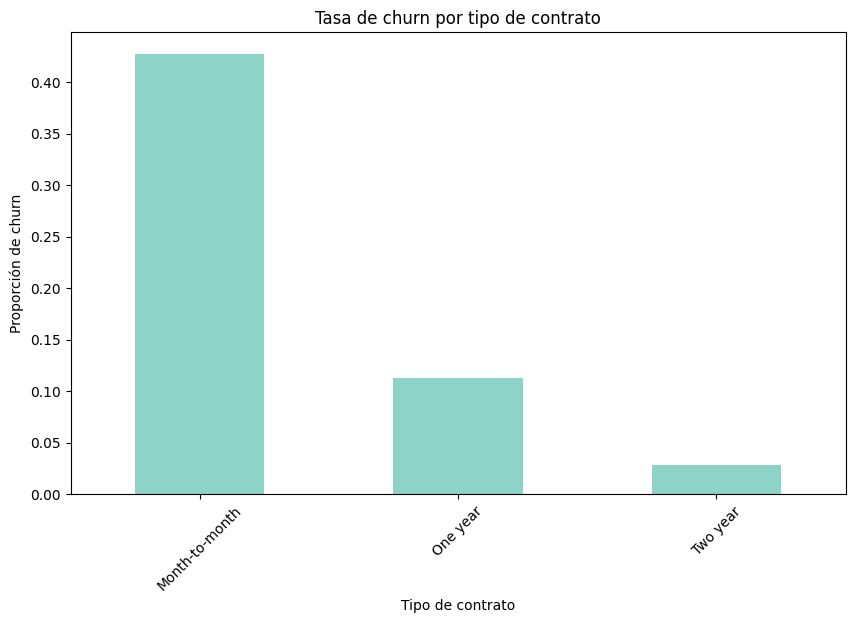

In [29]:
import matplotlib.pyplot as plt

churn_by_contract = df.groupby("type")["churn"].mean()

churn_by_contract.plot(kind = "bar", cmap = "Set3", figsize = [10, 6])

plt.title("Tasa de churn por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Proporción de churn")
plt.xticks(rotation = 45)
plt.show()

#### Observaciones

Se observa una diferencia muy marcada en la tasa de cancelación según el tipo de contrato. Los clientes con contratos mensuales presentan una probabilidad de churn significativamente mayor, mientras que los contratos de uno y dos años muestran una retención mucho más alta.

Esto sugiere que los contratos de mayor duración generan mayor estabilidad y compromiso del cliente con la empresa.

### 3.3 Churn vs cargo mensual

In [30]:
# Visualizar información estadística
df.groupby("churn")["monthly_charges"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,5174.00,61.27,31.09,18.25,25.10,64.43,88.40,118.75
1,1869.00,74.44,24.67,18.85,56.15,79.65,94.20,118.35


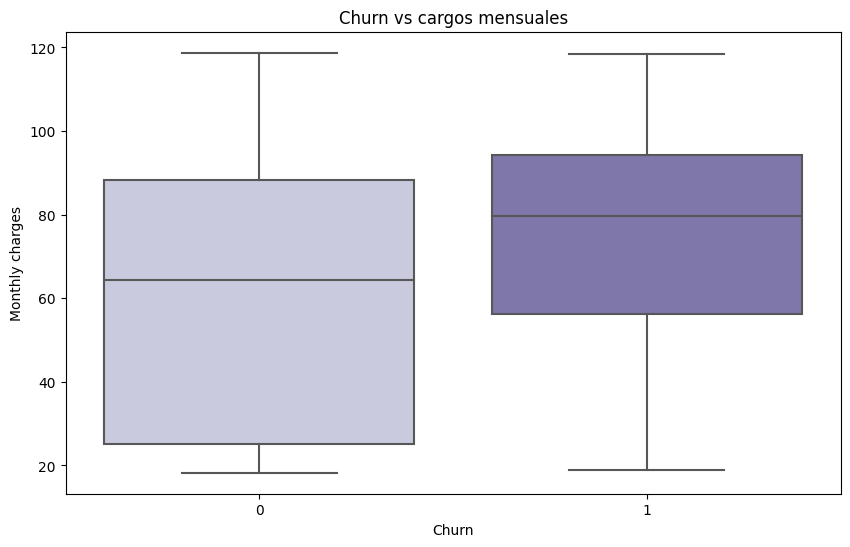

In [31]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df, x = "churn", y = "monthly_charges", palette = "Purples")

plt.title("Churn vs cargos mensuales")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly charges")
plt.show()

#### Observaciones
Los clientes que cancelan el servicio tienden a presentar cargos mensuales ligeramente más altos en comparación con los clientes activos.

El análisis descriptivo confirma esta tendencia, mostrando diferencias en la media y en los cuartiles, lo que sugiere que el costo del servicio puede influir en la decisión de cancelación.

### 3.4 Churn vs ternure

In [32]:
# Visualizar información estadística
df.groupby("churn")["tenure_months"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,5174.00,38.15,24.46,0.00,15.23,38.57,61.90,73.03
1,1869.00,18.25,19.81,1.00,2.03,10.13,29.43,73.03


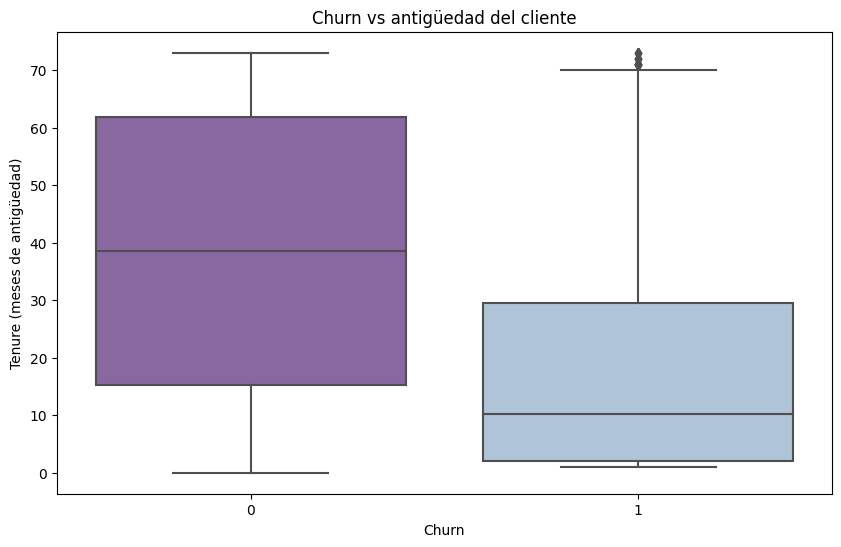

In [33]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df, x = "churn", y = "tenure_months", palette = "BuPu_r")

plt.title("Churn vs antigüedad del cliente")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (meses de antigüedad)")
plt.show()

#### Observaciones

Se observa que los clientes que cancelan el servicio tienen una menor antigüedad en la empresa en comparación con los clientes activos.

El análisis descriptivo refuerza este patrón, indicando que la mayor parte de las cancelaciones ocurre en etapas tempranas de la relación con el cliente, lo que sugiere que los primeros meses son críticos para la retención.

### 3.5 Churn vs método de pago

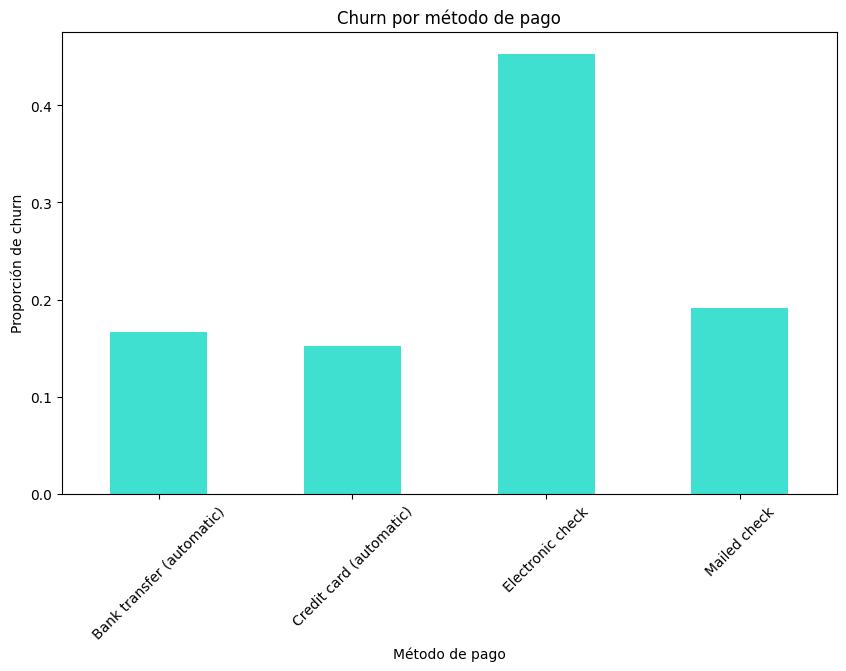

In [34]:
churn_by_payment = df.groupby("payment_method")["churn"].mean()

churn_by_payment.plot(kind = "bar", color = "turquoise", figsize = [10, 6])

plt.title("Churn por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Proporción de churn")
plt.xticks(rotation = 45)
plt.show()

#### Observaciones
Se observa que el método de pago influye en la tasa de cancelación. Los clientes que utilizan pago electrónico presentan una mayor proporción de churn en comparación con otros métodos como transferencias automáticas o tarjetas. Esto podría estar relacionado con un menor nivel de automatización o compromiso en la permanencia del servicio.

### 3.6 Churn vs servicios de internet

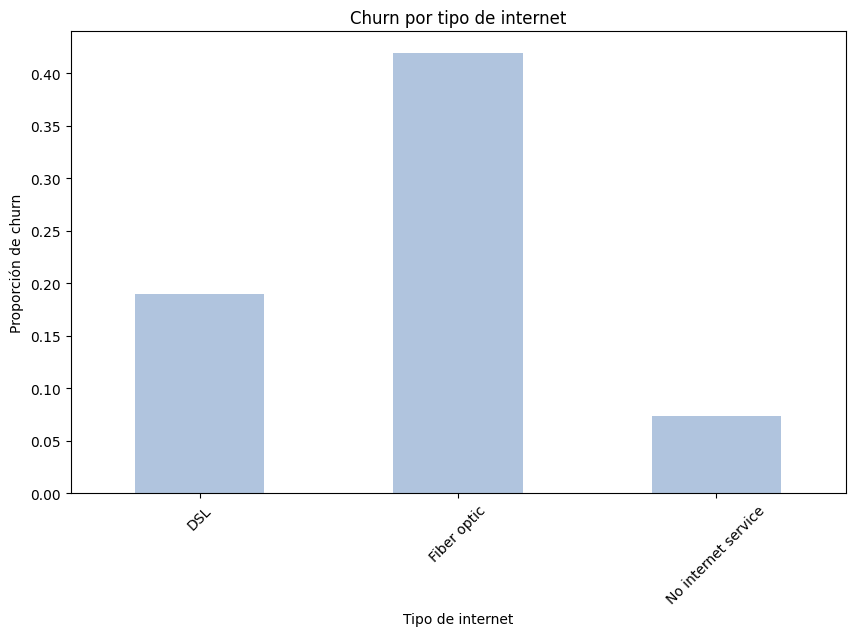

In [35]:
churn_by_internet = df.groupby("internet_service")["churn"].mean()

churn_by_internet.plot(kind = "bar", color = "lightsteelblue", figsize = [10, 6])

plt.title("Churn por tipo de internet")
plt.xlabel("Tipo de internet")
plt.ylabel("Proporción de churn")
plt.xticks(rotation = 45)
plt.show()

#### Observaciones
Se observa que los clientes con servicio de fibra óptica presentan una mayor tasa de cancelación en comparación con otros tipos de internet. Esto podría indicar diferencias en la percepción del servicio o expectativas más altas asociadas a este tipo de conexión, lo cual impacta en la probabilidad de abandono.

## 4. Ingeniería de Caterísticas

Con base en el análisis exploratorio realizado, se construirán nuevas variables derivadas que permitan representar mejor el comportamiento de los clientes.

Estas características buscan capturar factores relevantes como la antigüedad del cliente, su nivel de gasto y su etapa dentro del ciclo de vida, lo cual podría mejorar la capacidad predictiva de los modelos de clasificación.

### 4.1 Variable de antigüedad del cliente

In [36]:
# Variable creada en la sección anterior
df[["begin_date", "end_date", "tenure_months"]].head()

,begin_date,end_date,tenure_months
0,2020-01-01,NaT,1.03
1,2017-04-01,NaT,34.53
2,2019-10-01,2019-12-01,2.03
3,2016-05-01,NaT,45.70
4,2019-09-01,2019-11-01,2.03


### 4.2 Sgmentación del nivel de gasto mensual

In [37]:
# Crear categorías de gasto mensual

df["monthly_charge_level"] = pd.cut(df["monthly_charges"], bins = 3, labels = ["Bajo", "Medio", "Alto"])

df["monthly_charge_level"].value_counts()

Bajo     2451
Medio    2439
Alto     2153
Name: monthly_charge_level, dtype: int64

### 4.3 Segmentación por etapa del cliente

In [38]:
# Esta segmentación será de especial utilidad debido a que el EDA mostró que churn es más alto al inicio
# Lógica a usar: 0–12 meses → Nuevo | 12–36 meses → Intermedio | 36+ → Antiguo

df["customer_stage"] = pd.cut(df["tenure_months"], bins = [0, 12, 36, 80], labels = ["Nuevo", "Intermedio", "Antiguo"])

df["customer_stage"].value_counts()

Antiguo       3051
Nuevo         2058
Intermedio    1923
Name: customer_stage, dtype: int64

### 4.4 Promedio histórico de gasto mensual

In [39]:
df["avg_monthly_spend"] = (df["total_charges"] / df["tenure_months"])

# Reemplazar posibles infinitos o NaN
df["avg_monthly_spend"] = df["avg_monthly_spend"].fillna(0)

In [40]:
# Verificar nuevas variables 

df[["tenure_months", "monthly_charge_level", "customer_stage", "avg_monthly_spend"]].head()

,tenure_months,monthly_charge_level,customer_stage,avg_monthly_spend
0,1.03,Bajo,Nuevo,28.89
1,34.53,Medio,Intermedio,54.72
2,2.03,Medio,Nuevo,53.19
3,45.70,Bajo,Antiguo,40.28
4,2.03,Medio,Nuevo,74.58


#### Observaciones

Se construyeron nuevas variables derivadas que permiten representar mejor el comportamiento y perfil de los clientes. 

La antigüedad del cliente, su nivel de gasto y su etapa dentro del ciclo de vida pueden aportar información adicional al modelo y ayudar a identificar patrones asociados a la cancelación del servicio.

Estas nuevas variables serán incorporadas en la siguiente etapa de preparación para modelado.

## 5. Preparación para modelado

En esta etapa se preparará el conjunto de datos para el entrenamiento de modelos de clasificación. Esto incluye la eliminación de variables que podrían introducir fuga de información, la selección de variables predictoras, la codificación de variables categóricas y la división del conjunto de datos en entrenamiento y prueba.

### 5.1 Eliminación de variables no predictivas y data leakage

Las variables a eliminar para que el modelo "no haga trampa" y se entrene correctamente son: 

- `customer ID` - Es solo un verificador y no tiene valor predictivo
- `end_date`- Define directamente churn (si lo dejamos el modelo aprenderá la respuesta)
- `end_date_filled`- Es derivada de `end_date`y también genera fuga
- `begin_date`- Ya se capturó esta información con `ternure_nonths`

In [41]:
# Eliminar variables no predictivas o con fuga de información

df_model = df.drop(columns=["customer_id", "begin_date", "end_date", "end_date_filled"])

df_model.head()

,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,churn,tenure_days,tenure_months,monthly_charge_level,customer_stage,avg_monthly_spend
0,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No phone service,0,31,1.03,Bajo,Nuevo,28.89
1,One year,No,Mailed check,56.95,1889.50,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,0,1036,34.53,Medio,Intermedio,54.72
2,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,1,61,2.03,Medio,Nuevo,53.19
3,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No phone service,0,1371,45.70,Bajo,Antiguo,40.28
4,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,1,61,2.03,Medio,Nuevo,74.58


### 5.2 Separación de variables predictoras y variables objetivo

In [42]:
# Separar variables independientes y variable objetivo
X = df_model.drop("churn", axis =1)
y = df_model["churn"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (7043, 22)
Dimensiones de y: (7043,)


### 5.3 Codificación de variables categóricas

In [43]:
# Codificar variables categóricas, utilizando drop_first = True para evitar redundancia y reducir multicolinealidad
X = pd.get_dummies(X, drop_first = True)

X.head()

,monthly_charges,total_charges,senior_citizen,tenure_days,tenure_months,avg_monthly_spend,type_One year,type_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,gender_Male,partner_Yes,dependents_Yes,internet_service_Fiber optic,internet_service_No internet service,online_security_No internet service,online_security_Yes,online_backup_No internet service,online_backup_Yes,device_protection_No internet service,device_protection_Yes,tech_support_No internet service,tech_support_Yes,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes,multiple_lines_No phone service,multiple_lines_Yes,monthly_charge_level_Medio,monthly_charge_level_Alto,customer_stage_Intermedio,customer_stage_Antiguo
0,29.85,29.85,0,31,1.03,28.89,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,56.95,1889.50,0,1036,34.53,54.72,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0
2,53.85,108.15,0,61,2.03,53.19,0,0,1,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,42.30,1840.75,0,1371,45.70,40.28,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1
4,70.70,151.65,0,61,2.03,74.58,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


### 5.4 División de entrenamiento y prueba

In [44]:
# Dividir datos en entrenamiento y prueba, utilizando stratify = y para mantener 73% activos y 27% churn en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5282, 35)
X_test: (1761, 35)
y_train: (5282,)
y_test: (1761,)


In [45]:
# Verificación del balance después del split
print("Distribución train:")
print(y_train.value_counts(normalize = True))

print("\n Distribución test:")
print(y_test.value_counts(normalize = True))

Distribución train:
0   0.73
1   0.27
Name: churn, dtype: float64

 Distribución test:
0   0.73
1   0.27
Name: churn, dtype: float64


#### Observaciones

Se preparó correctamente el conjunto de datos para el entrenamiento de modelos, eliminando variables con potencial fuga de información y conservando únicamente aquellas con valor predictivo. Posteriormente se codificaron las variables categóricas y se realizó a división entre entrenamiento y prueba, manteniendo la proporción original de la variable objetivo en ambos conjuntos gracias al uso de estratificación.

Esto garantiza que tanto el entrenamiento como la evaluación del modelo se realicen sobre distribuciones representativas del problema original, reduciendo sesgos y mejorando la confiabilidad de las métricas obtenidas.

## 6. Entrenamiento y Evaluación de Modelos

En esta etapa se evaluarán distintos modelos de clasificación para predecir churn.

Aunque la métrica principal del proyecto es **AUC-ROC**, se utilizarán también métricas complementarias como **F1-score** y **accuracy** para analizar el comportamiento de los modelos, especialmente considerando el desbalance moderado de clases y la importancia estratégica de detectar correctamente clientes en riesgo de cancelación.

### 6.1 DummyClassifier

In [46]:
# Prueba de cordura

# Crear modelo base
dummy_model = DummyClassifier(strategy = "most_frequent")

# Entrenar
dummy_model.fit(X_train, y_train)

# Predicciones
dummy_train_pred = dummy_model.predict(X_train)
dummy_test_pred = dummy_model.predict(X_test)

# Métricas
dummy_train_f1 = f1_score(y_train, dummy_train_pred)
dummy_test_f1 = f1_score(y_test, dummy_test_pred)

dummy_train_acc = accuracy_score(y_train, dummy_train_pred)
dummy_test_acc = accuracy_score(y_test, dummy_test_pred)

print("DummyClassifier - Train")
print("F1-score:", dummy_train_f1)
print("Accuracy:", dummy_train_acc)

print("\nDummyClassifier - Test")
print("F1-score:", dummy_test_f1)
print("Accuracy:", dummy_test_acc)

DummyClassifier - Train
F1-score: 0.0
Accuracy: 0.7345702385460053

DummyClassifier - Test
F1-score: 0.0
Accuracy: 0.7348097671777399


#### Observaciones

El DummyClassifier (Prueba de Cordura) alcanza una accuracy cercana al 73%, lo cual coincide con la proporción de la clase mayoritaria en el dataset. Sin embargo, obtiene un F1-score de 0, ya que no logra identificar correctamente ningún caso de churn.

Esto demuestra que la accuracy por sí sola no es suficiente para evaluar este problema y justifica el uso de métricas como F1-score para medir de forma más adecuada la capacidad del modelo para detectar clientes en riesgo de cancelación.

### 6.2 Logistic Regression

In [47]:
# Crear modelo
log_model = LogisticRegression(random_state = 42, max_iter = 1000)

# Entrenar
log_model.fit(X_train, y_train)

# Predicciones
log_train_pred = log_model.predict(X_train)
log_test_pred = log_model.predict(X_test)

# Métricas
log_train_f1 = f1_score(y_train, log_train_pred)
log_test_f1 = f1_score(y_test, log_test_pred)

log_train_acc = accuracy_score(y_train, log_train_pred)
log_test_acc = accuracy_score(y_test, log_test_pred)

print("Logistic Regression - Train")
print("F1-score:", log_train_f1)
print("Accuracy:", log_train_acc)

print("\nLogistic Regression - Test")
print("F1-score:", log_test_f1)
print("Accuracy:", log_test_acc)

Logistic Regression - Train
F1-score: 0.5954077593032462
Accuracy: 0.8065126845891708

Logistic Regression - Test
F1-score: 0.5710872162485066
Accuracy: 0.7961385576377058


#### Observaciones

Podemos observar que el modelo de regresión logística mejora considerablemente el desempeño del modelo base, logrando identificar correctamente casos de churn y alcanzando un F1-score de 0.57 en el conjunto de prueba. 

Además, la diferencia entre las métricas de entrenamiento y prueba es pequeña, lo que indica buena capacidad de generalización y ausencia de sobreajuste significativo. Aunque el desempeño es aceptable, todavía se encuentra por debajo del umbral objetivo planteado, por lo que se explorarán modelos más complejos.

### 6.3 Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

# Crear modelo
rf_model = RandomForestClassifier(random_state = 42, n_estimators = 200)

# Entrenar
rf_model.fit(X_train, y_train)

# Predicciones
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Métricas
rf_train_f1 = f1_score(y_train, rf_train_pred)
rf_test_f1 = f1_score(y_test, rf_test_pred)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

print("Random Forest - Train")
print("F1-score:", rf_train_f1)
print("Accuracy:", rf_train_acc)

print("\nRandom Forest - Test")
print("F1-score:", rf_test_f1)
print("Accuracy:", rf_test_acc)

Random Forest - Train
F1-score: 0.9978571428571428
Accuracy: 0.9988640666414237

Random Forest - Test
F1-score: 0.5851197982345523
Accuracy: 0.8131743327654741


#### Observaciones
El modelo Random Forest logra un desempeño ligeramente superior a la regresión logística en el conjunto de prueba, alcanzando un F1-score de 0.59. Sin embargo, presenta un sobreajuste significativo, ya que obtiene métricas casi perfectas en entrenamiento pero una reducción considerable en prueba.

Esto nos indica que el modelo está memorizando patrones específicos del conjunto de entrenamiento y perdiendo capacidad de generalización, por lo que sería necesario ajustar hiperparámetros para mejorar su desempeño.

### 6.4 Random Forest (ajustado)

In [49]:
rf_tuned = RandomForestClassifier(random_state = 42, n_estimators = 200, max_depth = 10, min_samples_split = 10, min_samples_leaf = 5)

# Entrenar
rf_tuned.fit(X_train, y_train)

# Predicciones
rf_tuned_train_pred = rf_tuned.predict(X_train)
rf_tuned_test_pred = rf_tuned.predict(X_test)

# Métricas
rf_tuned_train_f1 = f1_score(y_train, rf_tuned_train_pred)
rf_tuned_test_f1 = f1_score(y_test, rf_tuned_test_pred)

rf_tuned_train_acc = accuracy_score(y_train, rf_tuned_train_pred)
rf_tuned_test_acc = accuracy_score(y_test, rf_tuned_test_pred)

print("Random Forest Ajustado - Train")
print("F1-score:", rf_tuned_train_f1)
print("Accuracy:", rf_tuned_train_acc)

print("\nRandom Forest Ajustado - Test")
print("F1-score:", rf_tuned_test_f1)
print("Accuracy:", rf_tuned_test_acc)

Random Forest Ajustado - Train
F1-score: 0.6884422110552764
Accuracy: 0.8591442635365392

Random Forest Ajustado - Test
F1-score: 0.5784695201037613
Accuracy: 0.8154457694491766


#### Observaciones
Tras ajustar los hiperparámetros del modelo Random Forest para reducir el sobreajuste, se observó una disminución importante en la diferencia entre las métricas de entrenamiento y prueba.

El F1-score en entrenamiento pasó de **0.9979** en el modelo original a **0.6884** en el modelo ajustado, mientras que en prueba pasó de **0.5851** a **0.5785**. Esto redujo considerablemente la brecha entre ambos conjuntos, mejorando la capacidad de generalización del modelo.

Sin embargo, aunque el modelo ajustado logró ser más estable, no consiguió mejorar el desempeño predictivo sobre el conjunto de prueba, manteniéndose ligeramente por debajo del modelo original. Esto indica que la regularización ayudó a controlar el sobreajuste, pero no aportó una mejora significativa en la detección de clientes con riesgo de cancelación.

### 6.5 Comparación de modelos

In [50]:
results = pd.DataFrame({
    "Modelo": ["DummyClassifier", "Logistic Regression", "Random Forest", "Random Forest Ajustado"],
    "Train F1": [dummy_train_f1, log_train_f1, rf_train_f1, rf_tuned_train_f1],
    "Test F1": [dummy_test_f1, log_test_f1, rf_test_f1, rf_tuned_test_f1],
    "Train Accuracy": [dummy_train_acc, log_train_acc, rf_train_acc,rf_tuned_train_acc],
    "Test Accuracy": [dummy_test_acc, log_test_acc, rf_test_acc, rf_tuned_test_acc]})

results

,Modelo,Train F1,Test F1,Train Accuracy,Test Accuracy
0,DummyClassifier,0.00,0.00,0.73,0.73
1,Logistic Regression,0.60,0.57,0.81,0.80
2,Random Forest,1.00,0.59,1.00,0.81
3,Random Forest Ajustado,0.69,0.58,0.86,0.82


#### Observaciones
La comparación de modelos muestra diferencias claras en desempeño y capacidad de generalización.

- El **DummyClassifier** obtuvo un F1-score de **0.00** tanto en entrenamiento como en prueba, con una accuracy de **0.73**, confirmando que predecir únicamente la clase mayoritaria no es suficiente para resolver el problema.

- La **Regresión Logística** logró una mejora importante, alcanzando un F1-score de **0.60** en entrenamiento y **0.57** en prueba, con accuracies de **0.81** y **0.80**, respectivamente. La pequeña diferencia entre ambos conjuntos indica una buena capacidad de generalización.

- El **Random Forest** alcanzó el mejor F1-score en prueba (**0.59**), pero presentó un sobreajuste severo, con un F1-score casi perfecto en entrenamiento (**1.00**) y una caída importante en prueba.

- Por su parte, el **Random Forest Ajustado** redujo considerablemente el sobreajuste, obteniendo un F1-score de **0.69** en entrenamiento y **0.58** en prueba, además de la mayor accuracy en prueba (**0.82**), aunque sin superar el mejor F1-score obtenido por el modelo original.

En general, los modelos basados en Random Forest mostraron un mejor desempeño predictivo que la Regresión Logística, aunque con distintos niveles de estabilidad. Se probará con una estrategia de balanceo para mejorar resultados.

### 6.6 Logistic Regression (balanceada)

In [51]:
from sklearn.linear_model import LogisticRegression

# Modelo con balance de clases
log_balanced = LogisticRegression(random_state = 42, max_iter = 1000, class_weight = "balanced")

# Entrenamiento
log_balanced.fit(X_train, y_train)

# Predicciones
log_bal_train_pred = log_balanced.predict(X_train)
log_bal_test_pred = log_balanced.predict(X_test)

# Métricas
log_bal_train_f1 = f1_score(y_train, log_bal_train_pred)
log_bal_test_f1 = f1_score(y_test, log_bal_test_pred)

log_bal_train_acc = accuracy_score(y_train, log_bal_train_pred)
log_bal_test_acc = accuracy_score(y_test, log_bal_test_pred)

print("Logistic Regression Balanceada - Train")
print("F1-score:", log_bal_train_f1)
print("Accuracy:", log_bal_train_acc)

print("\nLogistic Regression Balanceada - Test")
print("F1-score:", log_bal_test_f1)
print("Accuracy:", log_bal_test_acc)

Logistic Regression Balanceada - Train
F1-score: 0.6355668645744982
Accuracy: 0.7559636501325255

Logistic Regression Balanceada - Test
F1-score: 0.627017841971113
Accuracy: 0.750709823963657


#### Observaciones
Al incorporar balanceo de clases mediante `class_weight='balanced'`, el modelo logró mejorar su capacidad para detectar clientes en riesgo de cancelación.

El F1-score en el conjunto de prueba aumentó de **0.57** a **0.63**, mientras que la diferencia entre entrenamiento (**0.64**) y prueba (**0.63**) se mantuvo mínima, indicando una excelente capacidad de generalización.

Aunque la accuracy disminuyó de **0.80** a **0.75**, este comportamiento es esperado, ya que el modelo prioriza la detección de la clase minoritaria, la cual representa mayor valor estratégico para el negocio.

### 6.7 Threshold Tuning (optimización de umbral)

In [52]:
import numpy as np

# Obtener probabilidades de churn
log_probs = log_balanced.predict_proba(X_test)[:, 1]

best_threshold = 0
best_f1 = 0

for threshold in np.arange(0.10, 0.90, 0.05):
    preds = (log_probs >= threshold).astype(int)
    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Mejor umbral:", best_threshold)
print("Mejor F1-score:", best_f1)

Mejor umbral: 0.6000000000000002
Mejor F1-score: 0.6304761904761905


### 6.8 Random Forest (balanceado)

In [53]:
rf_balanced = RandomForestClassifier(random_state = 42, n_estimators = 300, max_depth = 12, min_samples_split = 10, min_samples_leaf = 5, class_weight = "balanced")

# Entrenar
rf_balanced.fit(X_train, y_train)

# Predicciones
rf_bal_train_pred = rf_balanced.predict(X_train)
rf_bal_test_pred = rf_balanced.predict(X_test)

# Métricas
rf_bal_train_f1 = f1_score(y_train, rf_bal_train_pred)
rf_bal_test_f1 = f1_score(y_test, rf_bal_test_pred)

rf_bal_train_acc = accuracy_score(y_train, rf_bal_train_pred)
rf_bal_test_acc = accuracy_score(y_test, rf_bal_test_pred)

print("Random Forest Balanceado - Train")
print("F1-score:", rf_bal_train_f1)
print("Accuracy:", rf_bal_train_acc)

print("\nRandom Forest Balanceado - Test")
print("F1-score:", rf_bal_test_f1)
print("Accuracy:", rf_bal_test_acc)

Random Forest Balanceado - Train
F1-score: 0.7867481505307173
Accuracy: 0.8744793638773192

Random Forest Balanceado - Test
F1-score: 0.648905803996194
Accuracy: 0.7904599659284497


#### Observaciones
El modelo Random Forest balanceado obtuvo el mejor desempeño general entre todos los modelos evaluados, alcanzando un F1-score de **0.65** en el conjunto de prueba y una accuracy de **0.79**.

En comparación con el modelo de Regresión Logística balanceada, logró una mejora en la capacidad de detección de churn, manteniendo al mismo tiempo un nivel de generalización aceptable.

Aunque se observa una diferencia entre entrenamiento (**0.79**) y prueba (**0.65**), el sobreajuste es considerablemente menor que en el Random Forest original, lo que indica un mejor equilibrio entre complejidad y capacidad predictiva.

Por esta razón, hasta este punto este modelo es considerado como el candidato principal para la solución final del problema.

Sin embargo, con el objetivo de seguir optimizando la capacidad predictiva y acercarnos al umbral recomendado de F1-score, se realizarán dos pruebas adicionales utilizando **CatBoostClassifier**: una configuración base y una versión balanceada, con el fin de evaluar si un modelo de boosting puede capturar patrones más complejos y mejorar la detección de clientes con riesgo de cancelación.

### 6.9 CatBoostClassifier

In [54]:
# Crear modelo CatBoost
cat_model = CatBoostClassifier(random_state = 42, iterations = 500, learning_rate = 0.05, depth = 6, loss_function= "Logloss", verbose = 0)

# Entrenar
cat_model.fit(X_train, y_train)

# Predicciones
cat_train_pred = cat_model.predict(X_train)
cat_test_pred = cat_model.predict(X_test)

# Métricas
cat_train_f1 = f1_score(y_train, cat_train_pred)
cat_test_f1 = f1_score(y_test, cat_test_pred)

cat_train_acc = accuracy_score(y_train, cat_train_pred)
cat_test_acc = accuracy_score(y_test, cat_test_pred)

print("atBoost - Train")
print("F1-score:", cat_train_f1)
print("Accuracy:", cat_train_acc)

print("\nCatBoost - Test")
print("F1-score:", cat_test_f1)
print("Accuracy:", cat_test_acc)

atBoost - Train
F1-score: 0.8413255360623781
Accuracy: 0.9229458538432412

CatBoost - Test
F1-score: 0.66167290886392
Accuracy: 0.8461101646791596


In [55]:
cat_balanced = CatBoostClassifier(random_state = 42, iterations = 500, learning_rate = 0.05, depth = 6, loss_function = "Logloss", auto_class_weights = "Balanced", verbose = 0)

cat_balanced.fit(X_train, y_train)

cat_bal_train_pred = cat_balanced.predict(X_train)
cat_bal_test_pred = cat_balanced.predict(X_test)

cat_bal_train_f1 = f1_score(y_train, cat_bal_train_pred)
cat_bal_test_f1 = f1_score(y_test, cat_bal_test_pred)

cat_bal_train_acc = accuracy_score(y_train, cat_bal_train_pred)
cat_bal_test_acc = accuracy_score(y_test, cat_bal_test_pred)

print("CatBoost Balanceado - Train")
print("F1-score:", cat_bal_train_f1)
print("Accuracy:", cat_bal_train_acc)

print("\nCatBoost Balanceado - Test")
print("F1-score:", cat_bal_test_f1)
print("Accuracy:", cat_bal_test_acc)

CatBoost Balanceado - Train
F1-score: 0.8497743391360413
Accuracy: 0.9117758424839076

CatBoost Balanceado - Test
F1-score: 0.6940726577437858
Accuracy: 0.8182850653038046


### 6.10 CatBoost tuned

In [56]:
cat_tuned = CatBoostClassifier(random_state = 42, iterations = 1000, learning_rate = 0.03, depth = 8, l2_leaf_reg = 5, 
                               auto_class_weights = "Balanced", loss_function = "Logloss", verbose = 0)

cat_tuned.fit(X_train, y_train)

cat_tuned_train_pred = cat_tuned.predict(X_train)
cat_tuned_test_pred = cat_tuned.predict(X_test)

cat_tuned_train_f1 = f1_score(y_train, cat_tuned_train_pred)
cat_tuned_test_f1 = f1_score(y_test, cat_tuned_test_pred)

cat_tuned_train_acc = accuracy_score(y_train, cat_tuned_train_pred)
cat_tuned_test_acc = accuracy_score(y_test, cat_tuned_test_pred)

print("CatBoost Ajustado - Train")
print("F1-score:", cat_tuned_train_f1)
print("Accuracy:", cat_tuned_train_acc)

print("\nCatBoost Ajustado - Test")
print("F1-score:", cat_tuned_test_f1)
print("Accuracy:", cat_tuned_test_acc)

CatBoost Ajustado - Train
F1-score: 0.9182930863380747
Accuracy: 0.9532374100719424

CatBoost Ajustado - Test
F1-score: 0.6779999999999999
Accuracy: 0.8171493469619534


### 6.11 Evaluación con AUC-ROC

Dado que la métrica principal del proyecto es **AUC-ROC**, se realizará una evaluación adicional sobre los modelos con mejor desempeño para medir formalmente su capacidad de discriminación entre clientes con churn y clientes activos.

Aunque durante la experimentación se utilizaron F1-score y accuracy como métricas complementarias, AUC-ROC será el criterio principal para la selección final del modelo.

In [57]:
# Probabilidades de los modelos
log_bal_probs = log_balanced.predict_proba(X_test)[:, 1]
rf_bal_probs = rf_balanced.predict_proba(X_test)[:, 1]
cat_probs = cat_model.predict_proba(X_test)[:, 1]
cat_bal_probs = cat_balanced.predict_proba(X_test)[:, 1]
cat_tuned_probs = cat_tuned.predict_proba(X_test)[:, 1]

# Cálculo de AUC-ROC
log_bal_auc = roc_auc_score(y_test, log_bal_probs)
rf_bal_auc = roc_auc_score(y_test, rf_bal_probs)
cat_auc = roc_auc_score(y_test, cat_probs)
cat_bal_auc = roc_auc_score(y_test, cat_bal_probs)
cat_tuned_auc = roc_auc_score(y_test, cat_tuned_probs)


print("Logistic Balanceada:", log_bal_auc)

print("Random Forest Balanceado:", rf_bal_auc)
print("CatBoost:", cat_auc)
print("CatBoost Balanceado:", cat_bal_auc)
print("CatBoost Ajustado:", cat_tuned_auc)

Logistic Balanceada: 0.8473484936240067
Random Forest Balanceado: 0.8632049088363688
CatBoost: 0.9023089601488008
CatBoost Balanceado: 0.896742170253749
CatBoost Ajustado: 0.8905862670404338


#### Observaciones

La evaluación mediante AUC-ROC muestra que los modelos basados en CatBoost obtuvieron la mejor capacidad de discriminación entre clientes activos y clientes con churn.

Tanto **CatBoost** como **CatBoost Balanceado** alcanzaron un AUC-ROC de **0.90**, superando el umbral máximo establecido por el proyecto (**AUC-ROC ≥ 0.88**). Esto indica que ambos modelos tienen una alta capacidad para separar correctamente ambas clases.

Aunque CatBoost obtuvo una accuracy ligeramente mayor (**0.85**), CatBoost Balanceado logró un mejor F1-score (**0.69** frente a **0.66**), lo cual es relevante porque el problema requiere identificar correctamente clientes en riesgo de cancelación.

### 6.12 Comparación de modelos (final)

In [58]:
# Tabla comparativa de todos los modelos evaluados

results = pd.DataFrame({
    "Modelo": [
        "DummyClassifier",
        "Logistic Regression",
        "Random Forest",
        "Random Forest Ajustado",
        "Logistic Regression Balanceada",
        "Logistic Regression Balanceada + Umbral",
        "Random Forest Balanceado",
        "CatBoost",
        "CatBoost Balanceado",
        "CatBoost Ajustado"],
    
    "Train F1": [
        dummy_train_f1,
        log_train_f1,
        rf_train_f1,
        rf_tuned_train_f1,
        log_bal_train_f1,
        log_bal_train_f1,
        rf_bal_train_f1,
        cat_train_f1,
        cat_bal_train_f1,
        cat_tuned_train_f1],
    
    "Test F1": [
        dummy_test_f1,
        log_test_f1,
        rf_test_f1,
        rf_tuned_test_f1,
        log_bal_test_f1,
        best_f1,
        rf_bal_test_f1,
        cat_test_f1,
        cat_bal_test_f1,
        cat_tuned_test_f1],
    
    "Train Accuracy": [
        dummy_train_acc,
        log_train_acc,
        rf_train_acc,
        rf_tuned_train_acc,
        log_bal_train_acc,
        log_bal_train_acc,
        rf_bal_train_acc,
        cat_train_acc,
        cat_bal_train_acc,
        cat_tuned_train_acc],
    
    "Test Accuracy": [
        dummy_test_acc,
        log_test_acc,
        rf_test_acc,
        rf_tuned_test_acc,
        log_bal_test_acc,
        np.nan,  # No se calculó accuracy con threshold tuning
        rf_bal_test_acc,
        cat_test_acc,
        cat_bal_test_acc,
        cat_tuned_test_acc],

    "Test AUC-ROC": [
        np.nan,          # Dummy no aplica
        np.nan,          # Logistic base no evaluado
        np.nan,          # RF base no evaluado
        np.nan,          # RF ajustado no evaluado
        log_bal_auc,
        log_bal_auc,     # mismo modelo con threshold tuning
        rf_bal_auc,
        cat_auc,
        cat_bal_auc,
        cat_tuned_auc]
})

# Ordenar por métrica principal AUC-ROC
results = results.sort_values(by = "Test AUC-ROC", ascending=False, na_position = "last")

# Mostrar tabla final redondeada
results.round(4)

,Modelo,Train F1,Test F1,Train Accuracy,Test Accuracy,Test AUC-ROC
7,CatBoost,0.84,0.66,0.92,0.85,0.90
8,CatBoost Balanceado,0.85,0.69,0.91,0.82,0.90
9,CatBoost Ajustado,0.92,0.68,0.95,0.82,0.89
6,Random Forest Balanceado,0.79,0.65,0.87,0.79,0.86
4,Logistic Regression Balanceada,0.64,0.63,0.76,0.75,0.85
5,Logistic Regression Balanceada + Umbral,0.64,0.63,0.76,NaN,0.85
0,DummyClassifier,0.00,0.00,0.73,0.73,NaN
1,Logistic Regression,0.60,0.57,0.81,0.80,NaN
2,Random Forest,1.00,0.59,1.00,0.81,NaN
3,Random Forest Ajustado,0.69,0.58,0.86,0.82,NaN


#### Observaciones

Se realizó una optimización adicional de hiperparámetros sobre CatBoost con el objetivo de mejorar el desempeño del modelo.

Aunque el modelo incrementó su F1-score en entrenamiento de **0.85** a **0.92**, el desempeño en prueba disminuyó de **0.69** a **0.68**, y su AUC-ROC bajó de **0.90** a **0.89**, lo que indica un aumento en el sobreajuste. Este resultado confirma que una mayor complejidad no siempre mejora la capacidad predictiva en datos no vistos.

La comparación final de todos los modelos muestra una evolución clara en el desempeño a medida que se incorporaron técnicas de balanceo, ajuste de umbrales y modelos más avanzados de boosting.

- El **DummyClassifier** confirmó que la accuracy por sí sola no es suficiente para este problema, obteniendo un F1-score de **0.00** a pesar de una accuracy de **0.73**, al predecir únicamente la clase mayoritaria.

- Los modelos de **Regresión Logística** mostraron una mejora importante, alcanzando hasta **0.63** de F1-score tras incorporar balanceo y optimización de umbral, además de un AUC-ROC de **0.85**, con una capacidad de generalización muy estable y bajo riesgo de sobreajuste.

- Por su parte, los modelos de **Random Forest** mejoraron la capacidad de detección de churn hasta un F1-score de **0.65** en su versión balanceada, acompañado de un AUC-ROC de **0.86**, aunque mostrando mayor tendencia al sobreajuste en comparación con la Regresión Logística.

- Finalmente, los modelos de **CatBoost** obtuvieron el mejor desempeño general. Tanto el modelo **CatBoost** como **CatBoost Balanceado** alcanzaron el mejor AUC-ROC con **0.90**, superando el umbral máximo de evaluación del proyecto. Sin embargo, el modelo **CatBoost Balanceado** logró el mejor F1-score en prueba con **0.69**, acompañado de una accuracy de **0.82**, logrando el mejor equilibrio entre capacidad predictiva, discriminación y generalización.

Aunque el modelo **CatBoost Ajustado** alcanzó mejores resultados en entrenamiento (**F1 = 0.92**), su desempeño en prueba disminuyó a **0.68** y su AUC-ROC a **0.89**, indicando un incremento en el sobreajuste.

Con base en estos resultados, el modelo **CatBoost Balanceado** es seleccionado como la solución final para el problema de predicción de churn, al ser el modelo con mejor capacidad para identificar clientes en riesgo de cancelación y mantener un desempeño robusto en datos no vistos, además de cumplir con la métrica principal de evaluación del proyecto.

## 7. Selección del Modelo Final

Tras evaluar múltiples modelos de clasificación, se seleccionó **CatBoost Balanceado** como modelo final para la solución del problema.

La selección se realizó considerando principalmente la métrica **AUC-ROC**, complementada con **F1-score** y **accuracy**, con el fin de evaluar no solo la capacidad de discriminación entre clases, sino también la capacidad de generalización y la relevancia estratégica para el negocio.

Este modelo alcanzó un **AUC-ROC de 0.90** en el conjunto de prueba, cumpliendo con el nivel más alto de evaluación establecido por el proyecto. Además, obtuvo un **F1-score de 0.69** y una **accuracy de 0.82**, lo que refleja un buen equilibrio entre capacidad de discriminación, precisión general y detección de clientes con riesgo de cancelación.

Aunque el modelo **CatBoost** sin balanceo obtuvo el mismo AUC-ROC (**0.90**) y una accuracy superior (**0.85**), se eligió **CatBoost Balanceado** porque mejoró la capacidad de identificación de la clase churn, que representa la prioridad principal del negocio.

#### Prioridad del negocio

En este problema, el error más crítico para el negocio es un **falso negativo**, es decir, cuando un cliente con intención de cancelar es clasificado como cliente estable. Este tipo de error implica perder la oportunidad de aplicar estrategias de retención, promociones o planes especiales para evitar la cancelación. 

Por esta razón, aunque la métrica principal del proyecto es **AUC-ROC**, durante la evaluación también se consideraron métricas complementarias como **F1-score** y **accuracy**, ya que permiten analizar con mayor detalle la efectividad del modelo para identificar correctamente clientes en riesgo y equilibrar precisión y recall.

## 8. Conclusiones y Recomendaciones

### 8.1 Principales hallazgos

El análisis exploratorio permitió identificar patrones claros asociados al churn:

- Los clientes con contratos **mensuales** presentan una tasa de cancelación significativamente más alta que aquellos con contratos de mayor duración.
- Los clientes con **mayores cargos mensuales** tienden a mostrar mayor probabilidad de abandono.
- La mayor parte de las cancelaciones ocurre en clientes con **baja antigüedad**, indicando que los primeros meses son críticos para la retención.
- Los métodos de pago electrónicos presentan mayores tasas de churn.
- Los clientes con servicio de **fibra óptica** muestran mayor propensión a cancelar.

Estos hallazgos fueron consistentes con los resultados obtenidos durante el modelado, reforzando la relevancia de estas variables en la predicción de churn.

### 8.2 Implicaciones de negocio
- Estos resultados sugieren que Interconnect puede mejorar su estrategia de retención enfocándose en clientes con mayor riesgo de abandono.
- En particular, los clientes nuevos con contratos mensuales y cargos elevados representan un segmento prioritario para acciones preventivas.
- El modelo final seleccionado, con un **AUC-ROC de 0.90**, permite identificar con alta capacidad de discriminación a los clientes con mayor probabilidad de cancelación, lo que facilita la implementación de estrategias de retención más oportunas y focalizadas.
- La empresa podría implementar campañas de fidelización temprana, promociones personalizadas o incentivos para migrar a contratos de mayor duración.

 ### 8.3 Recomendaciones

Con base en los hallazgos y resultados del modelo, se recomienda:

1. Implementar el modelo **CatBoost Balanceado** como sistema de alerta temprana para identificar clientes con alta probabilidad de churn, aprovechando su alto desempeño (**AUC-ROC = 0.90**) y su capacidad de discriminación.

2. Priorizar acciones comerciales sobre clientes nuevos y con contratos mensuales, ya que representan el segmento con mayor riesgo de cancelación.

3. Diseñar estrategias de migración hacia contratos de uno o dos años, con el objetivo de mejorar la retención a largo plazo.

4. Analizar con mayor profundidad la experiencia de usuarios con servicio de fibra óptica para identificar posibles causas de cancelación y oportunidades de mejora.

5. Continuar enriqueciendo el modelo con nuevas variables que permitan mejorar su capacidad predictiva y fortalecer futuras estrategias de retención.

### 8.4 Limitaciones

Aunque el modelo final obtuvo un desempeño sólido y alcanzó un **AUC-ROC de 0.90**, todavía existe margen de mejora en métricas complementarias como **F1-score**, especialmente en la capacidad de identificar con mayor precisión a todos los clientes con churn.

Esto sugiere que podrían existir variables relevantes no incluidas en el dataset actual, como historial de interacciones con soporte, satisfacción del cliente o eventos de facturación.

Futuras iteraciones podrían incorporar información adicional y explorar técnicas más avanzadas de optimización para mejorar aún más el desempeño general del modelo.

# Conclusión Final

El presente proyecto abordó un problema de **clasificación binaria**, cuyo objetivo fue predecir la cancelación de clientes (*churn*) para el operador de telecomunicaciones Interconnect.

A lo largo del análisis se integraron múltiples fuentes de información relacionadas con contratos, características personales y servicios contratados, permitiendo construir una base consolidada de **7,043 clientes** para su análisis y modelado.

El análisis exploratorio permitió identificar factores clave asociados a la cancelación, destacando principalmente los contratos mensuales, la baja antigüedad de los clientes, cargos mensuales elevados y ciertos métodos de pago como variables relevantes en el comportamiento de churn.

Durante la etapa de modelado se evaluaron distintos enfoques, incluyendo modelos base, modelos lineales, modelos de ensamble y algoritmos de boosting, aplicando técnicas de balanceo de clases, ajuste de hiperparámetros y optimización de umbrales.

El mejor resultado fue obtenido por el modelo **CatBoost Balanceado**, alcanzando un **AUC-ROC de 0.90**, un **F1-score de 0.69** y una **accuracy de 0.82** en el conjunto de prueba, superando el umbral máximo de evaluación establecido para la métrica principal del proyecto y representando una mejora considerable frente a los modelos iniciales.

Aunque aún existe margen de mejora en métricas complementarias como F1-score, el proceso permitió construir una solución robusta, interpretable y alineada con las necesidades del negocio, capaz de servir como una herramienta de apoyo para estrategias de retención y reducción de pérdida de clientes.